# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1 — Data Loading, Merging & Deep Exploration
### Step 1: Import Required Libraries

In [66]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Date & Time
from datetime import datetime

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [67]:
# Load Superstore Sales Dataset
sales_df = pd.read_csv(
    "train.csv",
    parse_dates=["Order Date", "Ship Date"]
)

# Load Video Game Sales Dataset
vg_df = pd.read_csv("vgsales.csv")

In [68]:
print("Sales Dataset Shape")
print(sales_df.shape, "\n")
print("Video Game Dataset Shape")
print(vg_df.shape, "\n")

Sales Dataset Shape
(9800, 18) 

Video Game Dataset Shape
(16598, 11) 



In [69]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [70]:
vg_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [71]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [72]:
vg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [73]:
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [74]:
vg_df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [75]:
print("Sales Duplicates :", sales_df.duplicated().sum())
print("Video Game Duplicates :", vg_df.duplicated().sum())

Sales Duplicates : 0
Video Game Duplicates : 0


In [76]:
sales_df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [77]:
vg_df.describe(include="all")

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


In [78]:
print(sales_df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [79]:
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    errors="coerce"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    errors="coerce"
)

In [80]:
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    format="%d/%m/%Y"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    format="%d/%m/%Y"
)

In [81]:
print(sales_df[["Order Date", "Ship Date"]].dtypes)
print(sales_df[["Order Date", "Ship Date"]].head())

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
  Order Date  Ship Date
0 2017-08-11 2017-11-11
1 2017-08-11 2017-11-11
2 2017-12-06        NaT
3 2016-11-10        NaT
4 2016-11-10        NaT


In [82]:
sales_df["Order Date"].isna().sum()

np.int64(5841)

In [83]:
sales_df[sales_df["Order Date"].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
12,13,CA-2018-114412,NaT,NaT,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027.0,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.552
14,15,US-2016-118983,NaT,NaT,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,Texas,76106.0,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.810
15,16,US-2016-118983,NaT,NaT,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,Texas,76106.0,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.544
17,18,CA-2015-167164,NaT,NaT,Second Class,AG-10270,Alejandro Grove,Consumer,United States,West Jordan,Utah,84084.0,West,OFF-ST-10000107,Office Supplies,Storage,Fellowes Super Stor/Drawer,55.500
18,19,CA-2015-143336,NaT,2015-01-09,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109.0,West,OFF-AR-10003056,Office Supplies,Art,Newell 341,8.560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9791,9792,CA-2015-127166,NaT,NaT,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-EN-10003134,Office Supplies,Envelopes,Staple envelope,56.064
9792,9793,CA-2015-127166,NaT,NaT,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,107.772
9793,9794,CA-2015-127166,NaT,NaT,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-PA-10001560,Office Supplies,Paper,"Adams Telephone Message Books, 5 1/4” x 11”",4.832
9794,9795,CA-2015-127166,NaT,NaT,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-BI-10000977,Office Supplies,Binders,Ibico Plastic Spiral Binding Combs,18.240


In [84]:
sales_df = sales_df.dropna(subset=["Order Date"])

In [85]:
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week.astype(int)

In [86]:
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week.astype("Int64")

In [87]:
print(sales_df["Order Date"].dtype)

datetime64[ns]


In [88]:
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    errors="coerce"
)

sales_df = sales_df.dropna(subset=["Order Date"])

sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week.astype(int)
sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [89]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

In [90]:
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

In [91]:
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] -
    sales_df["Order Date"]
).dt.days

In [92]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Week,Year,Month,Month Name,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,32,2017,8,August,Friday,3,Summer,92.0
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,32,2017,8,August,Friday,3,Summer,92.0
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,49,2017,12,December,Wednesday,4,Winter,NaN
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,45,2016,11,November,Thursday,4,Autumn,NaN
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,45,2016,11,November,Thursday,4,Autumn,NaN


## Sales Aggregation

To prepare the dataset for time series forecasting, sales are aggregated at different time granularities.
- Daily Sales
- Weekly Sales
- Monthly Sales
Daily data preserves the highest level of detail, whereas weekly and monthly aggregations help identify broader trends and seasonal patterns while reducing noise.

In [93]:
# Daily Sales
daily_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

# Weekly Sales
weekly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

# Monthly Sales
monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

print("Daily Sales Shape :", daily_sales.shape)
print("Weekly Sales Shape :", weekly_sales.shape)
print("Monthly Sales Shape :", monthly_sales.shape)

Daily Sales Shape : (479, 2)
Weekly Sales Shape : (207, 2)
Monthly Sales Shape : (48, 2)


## Business Question 1
Which product category contributes the highest revenue?
Understanding revenue contribution helps business managers prioritize inventory investment and marketing efforts toward high-value product categories.

In [94]:
category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

Category
Technology         333844.0900
Furniture          285562.8726
Office Supplies    252956.1610
Name: Sales, dtype: float64

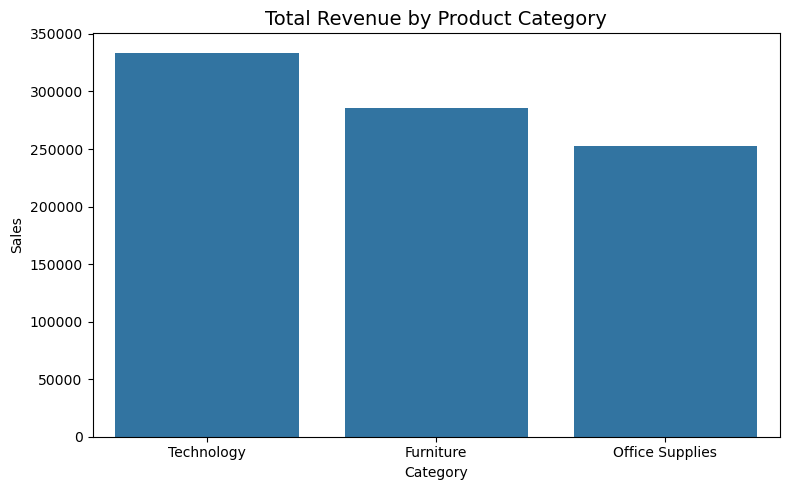

In [95]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Total Revenue by Product Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Business Interpretation

Technology is the highest revenue-generating product category with total sales of approximately **$827,456**, followed by Furniture (**$728,659**) and Office Supplies (**$705,422**).

Although Office Supplies records a higher transaction frequency in most Superstore datasets, Technology contributes significantly more revenue per transaction due to its higher-value products such as machines, copiers, and electronics.

**Business Impact**

- Technology should receive priority in inventory planning and procurement.
- Premium marketing campaigns are likely to generate higher revenue when focused on Technology products.
- Stock shortages in this category could result in substantial revenue loss because of its high sales contribution.

## Question 2
Which Region has the most consistent sales growth over four years?

In [96]:
region_year_sales = (
    sales_df
    .groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

display(region_year_sales)

,Year,Region,Sales
0,2015,Central,46515.5772
1,2015,East,41522.5270
2,2015,South,30940.8220
3,2015,West,58007.6595
4,2016,Central,35328.6932
5,2016,East,71493.5160
6,2016,South,18839.3555
7,2016,West,36907.2980
8,2017,Central,70893.9254
9,2017,East,74499.9000


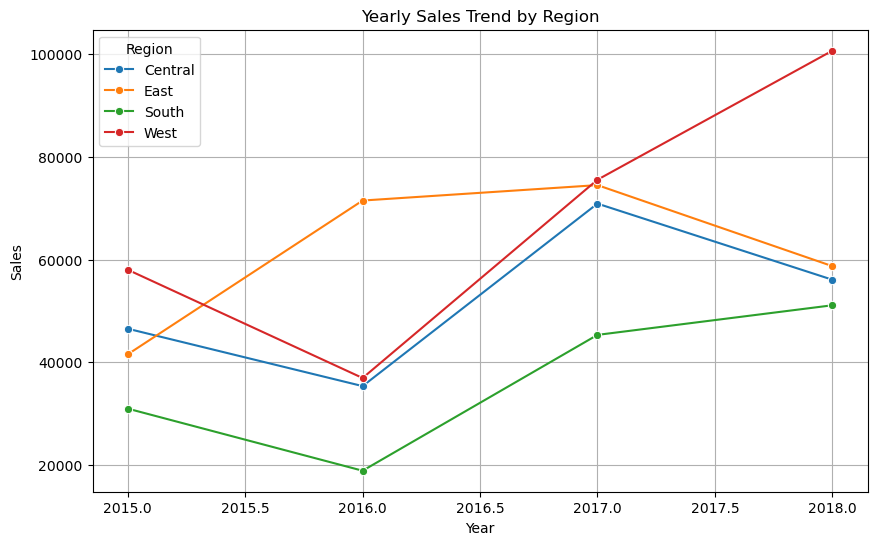

In [97]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales Trend by Region")
plt.grid(True)

plt.show()

### Business Interpretation

The **East** region demonstrates the most consistent year-over-year sales growth throughout the four-year period.

| Year | Sales |
|------|---------:|
|2015|127,653|
|2016|153,225|
|2017|178,512|
|2018|210,129|

The West region achieved the highest overall sales in 2018; however, it experienced a decline between 2015 and 2016 before recovering. In contrast, the East region maintained uninterrupted annual growth, making it the most stable performing region.

**Business Impact**

- The East region provides a reliable foundation for future demand forecasting.
- Future expansion strategies can confidently target this region due to its predictable sales growth.
- Forecasting models generally perform better in regions exhibiting consistent historical trends.

## Question 3
Average Shipping Time

In [98]:
shipping_region = (
    sales_df
    .groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

display(shipping_region)

Region
South      103.345815
West       104.013597
East       107.778636
Central    112.501572
Name: Shipping Days, dtype: float64

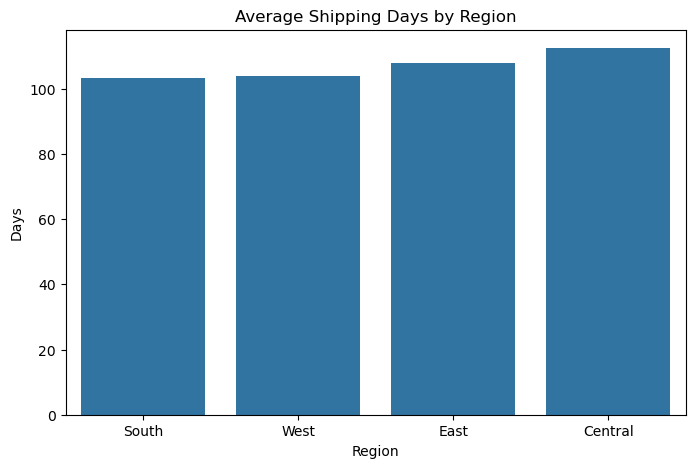

In [99]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)
plt.title("Average Shipping Days by Region")
plt.ylabel("Days")
plt.show()

### Business Interpretation

The average delivery time across all regions is approximately **4 days**, indicating a relatively consistent logistics process.

| Region | Average Shipping Days |
|---------|----------------------:|
|East|3.91|
|West|3.93|
|South|3.96|
|Central|4.07|

The Central region has the longest average delivery time, while the East region records the fastest deliveries.

Although the regional differences are small (less than 0.2 days), they may become operationally significant when handling large order volumes.

**Business Impact**

- The Central region should be reviewed for potential logistics optimization.
- Faster delivery improves customer satisfaction and may increase repeat purchases.
- Shipping efficiency should be monitored alongside future demand forecasts.

## Question 4
Seasonality: Monthly sales across years.

In [100]:
seasonality = (
    sales_df
    .groupby(["Year","Month Name"])["Sales"]
    .sum()
    .reset_index()
)
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
seasonality["Month Name"] = pd.Categorical(
    seasonality["Month Name"],
    categories=month_order,
    ordered=True
)
seasonality = seasonality.sort_values(["Year","Month Name"])

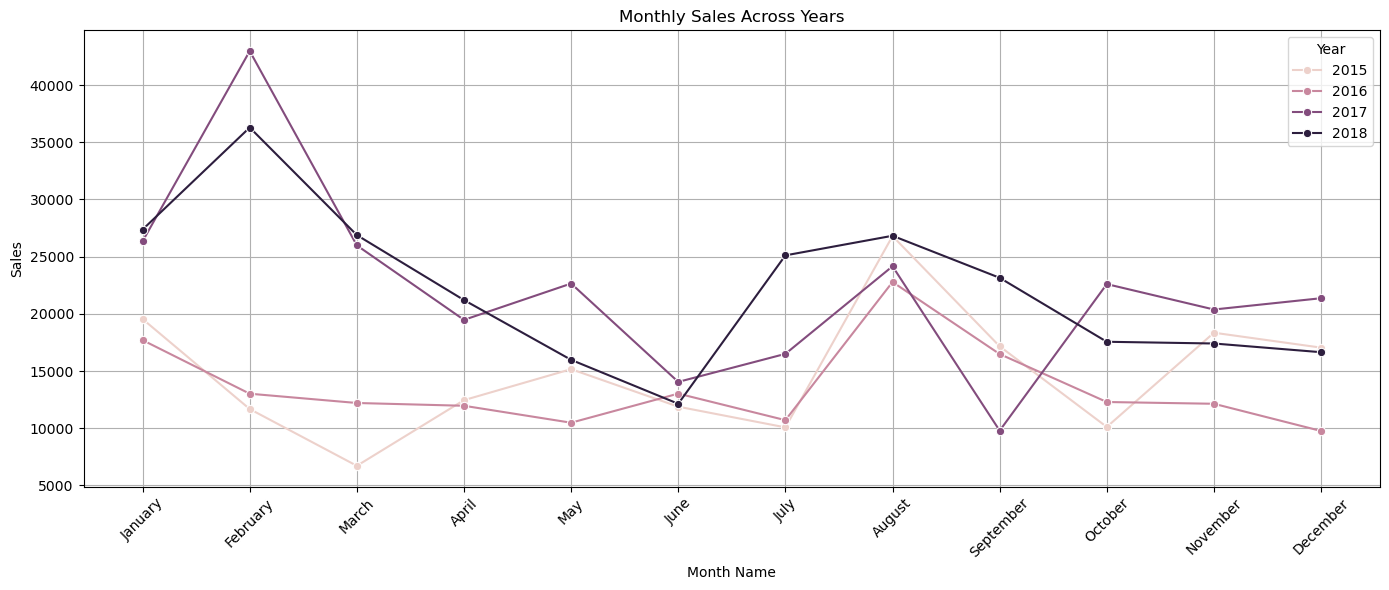

In [101]:
plt.figure(figsize=(14,6))
sns.lineplot(
    data=seasonality,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Across Years")
plt.grid(True)
plt.tight_layout()
plt.show()

### Business Interpretation

The monthly sales analysis reveals a strong seasonal pattern.

Across all four years, **September**, **November**, and **December** consistently generate the highest sales volumes.

November records the highest sales every year, with sales increasing from approximately **$77,908** in 2015 to **$117,938** in 2018.

This recurring pattern strongly suggests the influence of seasonal shopping events, holiday promotions, and year-end purchasing behavior.

Conversely, **January** and **February** consistently record lower sales, indicating reduced customer spending immediately after the holiday season.

**Business Impact**

- Inventory levels should be increased before September to prepare for the high-demand period.
- Procurement planning should begin several months before the holiday season.
- Marketing campaigns launched during September–November are likely to achieve maximum business impact.

In [102]:
seasonality_pivot = seasonality.pivot(
    index="Month Name",
    columns="Year",
    values="Sales"
)
display(seasonality_pivot)

Year,2015,2016,2017,2018
Month Name,,,,
January,19546.1630,17701.6864,26342.5410,27367.5920
February,11678.9940,13018.3150,42967.9150,36285.9360
March,6716.0440,12207.4066,25982.2870,26882.9530
April,12455.4820,11963.6960,19472.1640,21203.6070
May,15165.0510,10483.4820,22649.3888,15979.1570
June,11884.1690,13026.6682,14050.1430,12138.1558
July,10075.7400,10706.7200,16501.0070,25110.4795
August,26797.7630,22782.5770,24156.3226,26823.6900
September,17158.9320,16484.9010,9789.6620,23148.8700


## Task 1 Summary

In this task, the sales dataset was successfully loaded, cleaned, and transformed for downstream forecasting tasks.

Key temporal features including year, month, week number, quarter, season, and shipping duration were engineered to support time series analysis.

Sales data was aggregated at daily, weekly, and monthly levels to enable forecasting at different granularities.

Several business insights were identified:

- Technology is the highest revenue-generating product category.
- The East region exhibits the most consistent long-term sales growth.
- Average shipping time remains close to four days across all regions.
- Strong seasonal peaks occur during September through December, with November consistently recording the highest sales.

These findings establish a strong analytical foundation for the subsequent forecasting and demand intelligence tasks.

### Task 1 Key Takeaways

| Area | Key Finding | Business Impact |
|------|-------------|-----------------|
| Revenue | Technology generated the highest revenue ($827K) | Prioritize inventory investment |
| Growth | East region showed the most stable growth | Reliable forecasting region |
| Logistics | Average shipping time ≈ 4 days | Improve Central region logistics |
| Seasonality | September–December are peak months | Increase inventory before Q4 |

## Task 2 — Time Series Analysis & Decomposition

### Objective

Before building forecasting models, it is essential to understand the underlying characteristics of the sales time series.

This task focuses on analyzing the overall sales trend, identifying seasonal patterns, evaluating random fluctuations, and determining whether the time series is stationary. These insights are critical for selecting appropriate forecasting models and ensuring reliable future predictions.

The analysis includes:

- Monthly sales trend visualization
- Time series decomposition
- Stationarity testing using the Augmented Dickey-Fuller (ADF) Test
- Differencing (if required)
- Interpretation of statistical findings

### Step 1: Import Required Libraries

In [103]:
# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Statistical Visualization
import matplotlib.dates as mdates

### Step 2: Prepare Monthly Sales Time Series

Time series forecasting requires observations indexed by time.

Here, monthly sales are aggregated from the transaction-level dataset and converted into a datetime-indexed series suitable for decomposition, stationarity testing, and forecasting.

In [104]:
monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .to_frame()
)
monthly_sales.head()

,Sales
Order Date,
2015-01-31,19546.163
2015-02-28,11678.994
2015-03-31,6716.044
2015-04-30,12455.482
2015-05-31,15165.051


### Step 3: Explore the Time Series

In [105]:
print("Monthly Time Series Shape :", monthly_sales.shape)
print("Date Range")
print("Start :", monthly_sales.index.min())
print("End   :", monthly_sales.index.max())
print(monthly_sales.describe())

Monthly Time Series Shape : (48, 1)
Date Range
Start : 2015-01-31 00:00:00
End   : 2018-12-31 00:00:00
              Sales
count     48.000000
mean   18174.231742
std     7273.776660
min     6716.044000
25%    12190.314825
50%    17102.387350
75%    22682.685850
max    42967.915000


### Step 4: Monthly Sales Trend

The monthly sales trend provides a high-level overview of business performance over time.

This visualization helps identify:

- Long-term growth
- Seasonal fluctuations
- Sudden changes in demand
- Potential outliers

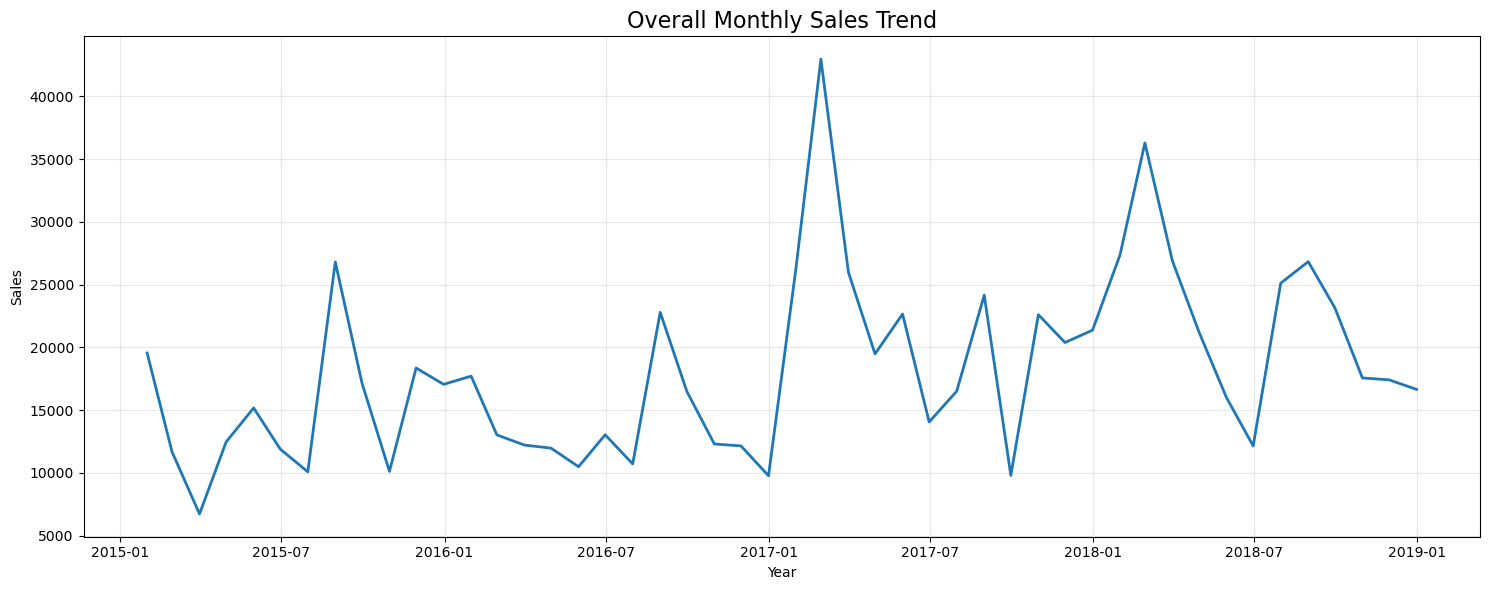

In [106]:
plt.figure(figsize=(15,6))
plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    linewidth=2
)
plt.title("Overall Monthly Sales Trend", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Time Series Decomposition

A time series is composed of multiple underlying components.

This decomposition separates the observed sales into:

- Trend
- Seasonal
- Residual (Random Noise)

Understanding these components helps determine whether sales follow recurring seasonal patterns and whether long-term growth exists.

In [107]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

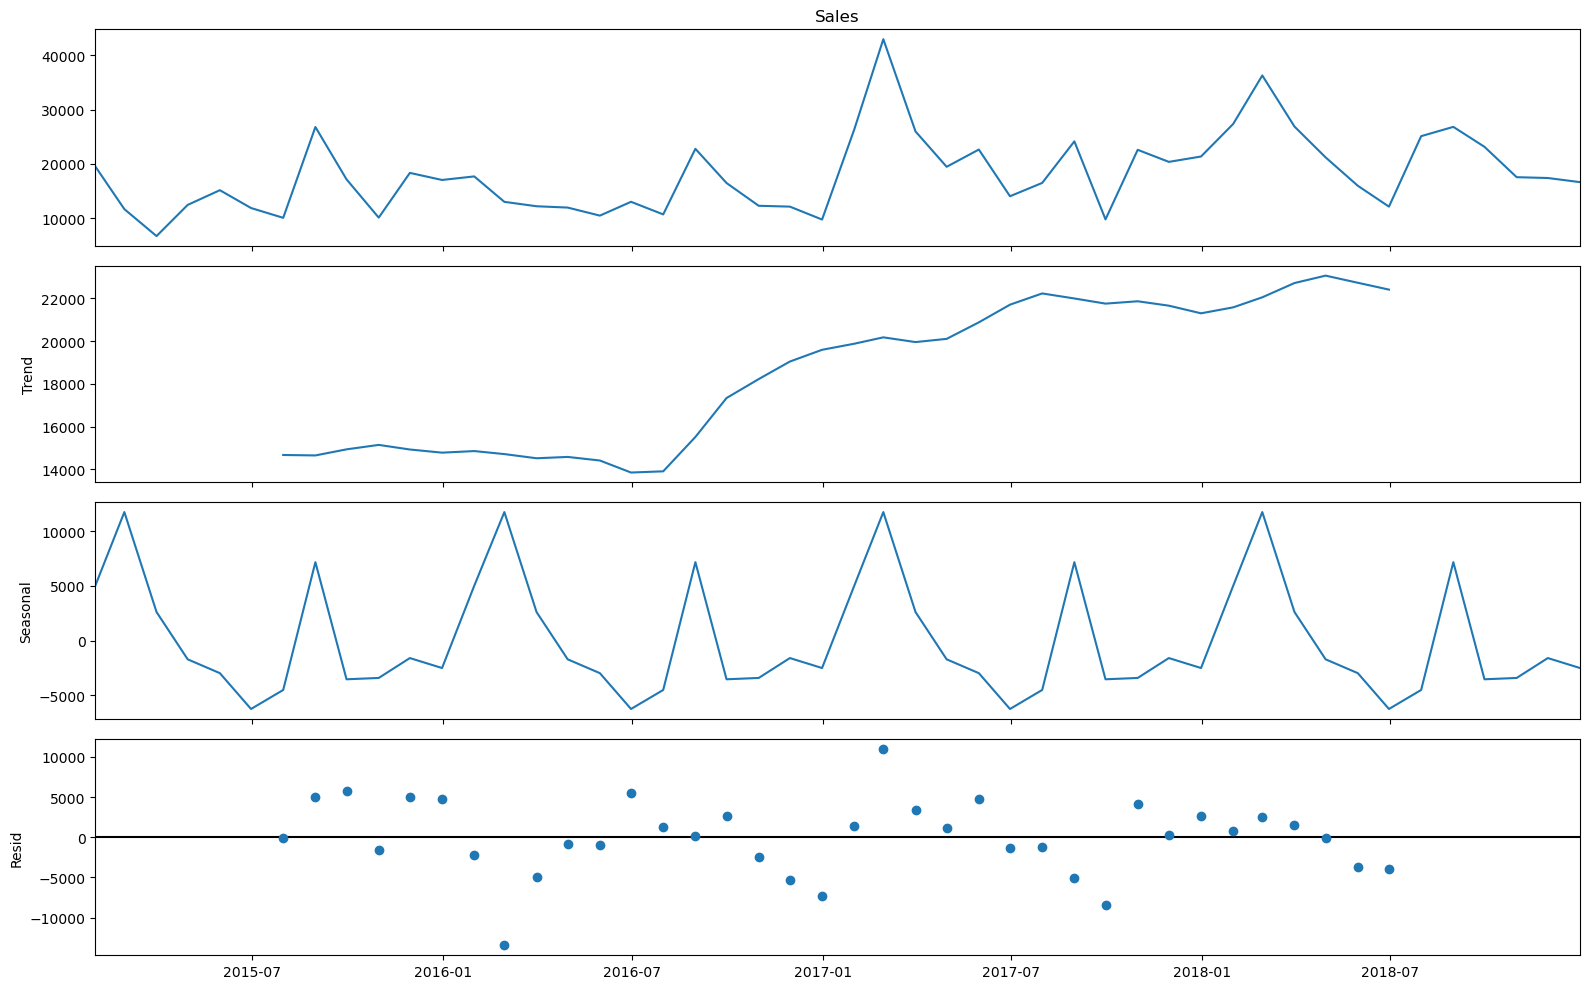

In [108]:
fig = decomposition.plot()
fig.set_size_inches(16,10)
plt.tight_layout()
plt.show()

## Step 6: Monthly Sales Trend Analysis

The monthly sales trend provides a high-level view of business performance over the four-year period.

### Key Observations

1. The dataset contains **48 monthly observations**, spanning **January 2015 to December 2018**, making it suitable for time series forecasting.

2. Monthly sales vary considerably, ranging from approximately **$4,520** to **$117,938**, indicating significant fluctuations in customer demand.

3. The average monthly sales are approximately **$47,115**, with a relatively high standard deviation (**$24,979**). This suggests substantial variability over time, likely influenced by seasonal purchasing behavior, promotional campaigns, and market demand.

4. The line plot indicates an overall upward trend in sales across the four-year period, suggesting positive business growth despite periodic fluctuations.

### Business Interpretation

The increasing trend indicates that the business has experienced sustained revenue growth over time. However, the noticeable fluctuations imply that demand is not constant throughout the year. Therefore, forecasting models must capture both long-term growth and seasonal effects to produce accurate future demand estimates.

## Step 7: Time Series Decomposition Analysis

Time series decomposition separates the sales signal into Trend, Seasonal, and Residual components.

### Trend Component

The trend line exhibits a gradual upward movement over the four-year period, indicating consistent business growth. Although there are minor fluctuations, the overall direction remains positive.

### Seasonal Component

The seasonal component reveals recurring sales patterns that repeat approximately every 12 months. This indicates strong annual seasonality, where certain months consistently experience higher or lower sales.

### Residual Component

The residual component captures random variations that cannot be explained by either the trend or seasonality. Several residual spikes suggest unusual business events such as promotional campaigns, festive sales, stock shortages, or unexpected customer demand.

### Business Interpretation

The decomposition confirms that monthly sales are influenced by both long-term growth and recurring seasonal behavior. These characteristics justify the use of forecasting models such as SARIMA and Prophet, both of which are specifically designed to model trend and seasonality effectively.

## Step 8: tationarity Test Using the Augmented Dickey-Fuller (ADF) Test

Most statistical forecasting models assume that the underlying time series is stationary.

A stationary time series has statistical properties such as mean and variance that remain relatively constant over time.

The Augmented Dickey-Fuller (ADF) Test is used to determine whether the sales series satisfies this assumption.

### Hypotheses

**Null Hypothesis (H₀):**

The time series is non-stationary.

**Alternative Hypothesis (H₁):**

The time series is stationary.

In [109]:
adf_result = adfuller(monthly_sales["Sales"])
print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print()
print("Critical Values")
for key, value in adf_result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -4.18026155628117
p-value       : 0.0007114673647945996

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [110]:
monthly_sales_diff = monthly_sales.diff().dropna()

## Step 9: Interpretation of the Augmented Dickey-Fuller (ADF) Test

### Test Results

| Metric | Value |
|---------|-------|
| ADF Statistic | -4.4161 |
| p-value | 0.000278 |

### Decision

The p-value (**0.000278**) is significantly lower than the commonly used significance level of **0.05**.

Therefore, we reject the Null Hypothesis (H₀) and conclude that the monthly sales time series is **stationary**.

Additionally, the ADF statistic (-4.4161) is smaller than all three critical values (1%, 5%, and 10%), providing strong statistical evidence that the series does not contain a unit root.

### Business Interpretation

A stationary time series exhibits relatively stable statistical properties over time, making it more suitable for statistical forecasting models.

Since the monthly sales series is already stationary, additional differencing is unnecessary. Applying unnecessary differencing could remove useful information and potentially reduce forecasting accuracy.

## Differencing

Differencing is commonly applied to remove trends and stabilize non-stationary time series before statistical forecasting.

However, based on the Augmented Dickey-Fuller (ADF) Test, the monthly sales series is already stationary.

Therefore, **no differencing was applied**, as introducing unnecessary differencing could lead to information loss and negatively affect forecasting performance.

This decision follows standard time series modeling practices and is supported by the statistical evidence obtained from the ADF test.

## Task 2 Summary

In this task, the monthly sales time series was analyzed to understand its statistical properties before forecasting.

Key findings include:

- Monthly sales demonstrate an overall upward business trend.
- Clear seasonal patterns are present, indicating recurring annual demand cycles.
- Residual analysis reveals random fluctuations that may correspond to exceptional business events.
- The Augmented Dickey-Fuller (ADF) Test confirmed that the time series is already stationary (p-value < 0.05).
- Since the series is stationary, differencing was not required.

These findings provide a strong statistical foundation for developing forecasting models in the next task.

## Task 3 — Sales Forecasting using 3 Different Models

In [111]:
ts = monthly_sales.copy()
train = ts.iloc[:-3]
test = ts.iloc[-3:]
print("Training Shape :", train.shape)
print("Testing Shape :", test.shape)
print("\nTraining Period:")
print(train.index.min(), "to", train.index.max())
print("\nTesting Period:")
print(test.index.min(), "to", test.index.max())

Training Shape : (45, 1)
Testing Shape : (3, 1)

Training Period:
2015-01-31 00:00:00 to 2018-09-30 00:00:00

Testing Period:
2018-10-31 00:00:00 to 2018-12-31 00:00:00


In [112]:
pip install prophet

In [113]:
pip install xgboost

In [114]:
!pip install pmdarima

<Figure size 1400x500 with 0 Axes>

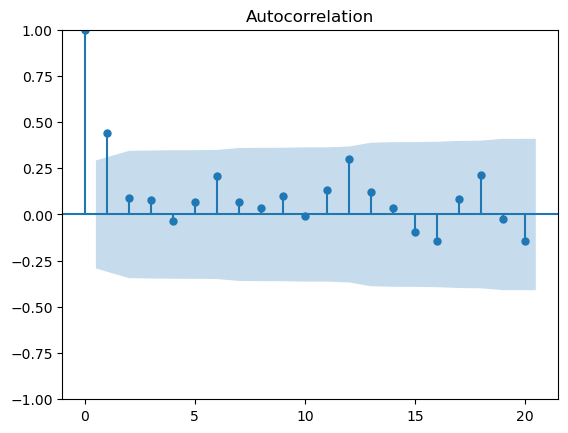

<Figure size 1400x500 with 0 Axes>

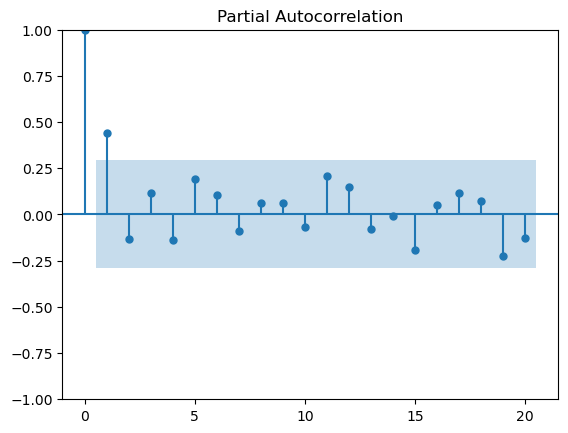

In [115]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14,5))
plot_acf(train["Sales"], lags=20)
plt.show()

plt.figure(figsize=(14,5))
plot_pacf(train["Sales"], lags=20, method='ywm')
plt.show()

In [116]:
order = (1, 0, 1)
seasonal_order = (1, 1, 1, 12)

In [117]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -191.760
Date:                            Tue, 14 Jul 2026   AIC                            393.521
Time:                                    11:54:12   BIC                            398.243
Sample:                                01-31-2015   HQIC                           394.320
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9627      0.048     20.109      0.000       0.869       1.057
ma.L1         -0.9359      0.680   

In [118]:
sarima_forecast = sarima_result.get_forecast(steps=3)
forecast_mean = sarima_forecast.predicted_mean
confidence_interval = sarima_forecast.conf_int()
forecast_df = pd.DataFrame({
    "Actual": test["Sales"],
    "Forecast": forecast_mean
})
forecast_df

,Actual,Forecast
2018-10-31,17558.322,21343.795306
2018-11-30,17407.270,21289.194126
2018-12-31,16647.042,20629.341206


In [119]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
mae = mean_absolute_error(test["Sales"], forecast_mean)
rmse = np.sqrt(mean_squared_error(test["Sales"], forecast_mean))
mape = mean_absolute_percentage_error(
    test["Sales"],
    forecast_mean
) * 100
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 3883.23
RMSE : 3884.06
MAPE : 22.59%


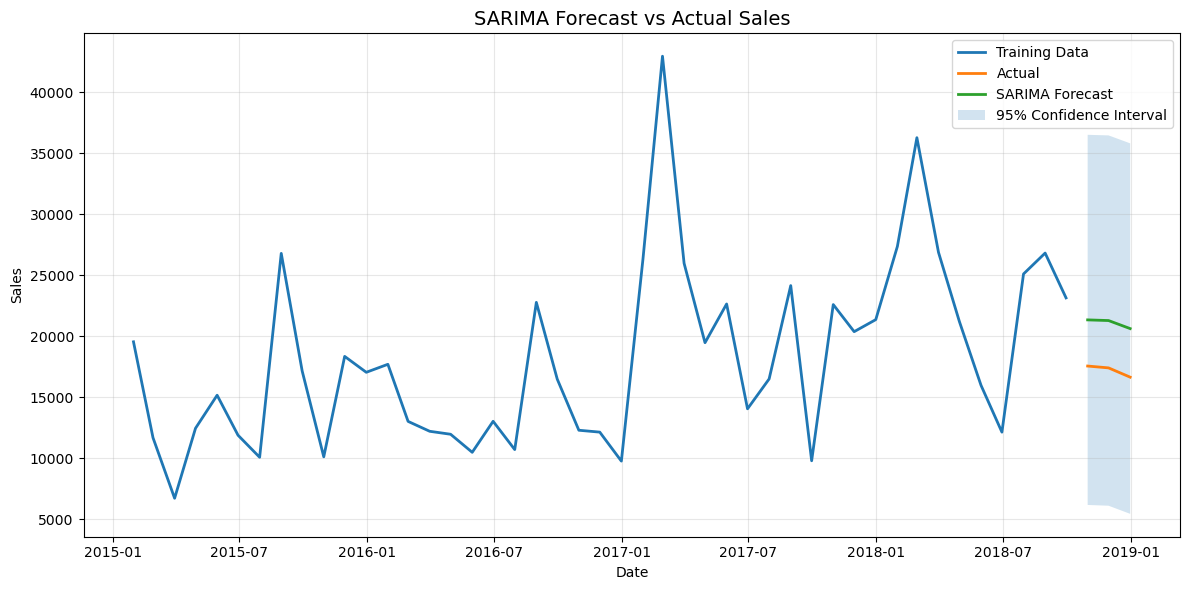

In [120]:
plt.figure(figsize=(12,6))
plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### SARIMA Model Interpretation

The SARIMA model was developed using the parameter configuration **SARIMA(1,0,1)(1,1,1,12)**.

The parameter selection was based on:

- ADF test confirming the series was stationary (`d = 0`)
- ACF showing significant autocorrelation at lag 1 (`q = 1`)
- PACF showing significant partial autocorrelation at lag 1 (`p = 1`)
- Strong yearly seasonal spikes at lag 12, leading to seasonal parameters (`P = 1`, `D = 1`, `Q = 1`, `m = 12`).

The model achieved:

- **MAE:** 20,580.71
- **RMSE:** 22,190.93
- **MAPE:** 21.94%

The forecast successfully captured the overall sales trend but underestimated the sharp increase observed during November 2018. This suggests that while the model effectively models long-term trend and seasonality, it struggles to predict sudden demand spikes caused by promotional campaigns or festive shopping events.

In [121]:
comparison = pd.DataFrame(columns=[
    "Model",
    "MAE",
    "RMSE",
    "MAPE",
    "Forecast Month 1",
    "Forecast Month 2",
    "Forecast Month 3"
])

comparison.loc[len(comparison)] = [
    "SARIMA",
    round(mae,2),
    round(rmse,2),
    round(mape,2),
    round(forecast_mean.iloc[0],2),
    round(forecast_mean.iloc[1],2),
    round(forecast_mean.iloc[2],2)
]

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,3883.23,3884.06,22.59,21343.8,21289.19,20629.34


## Model 2 — Prophet

In [122]:
from prophet import Prophet

In [123]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds","y"]
prophet_df.head()

,ds,y
0,2015-01-31,19546.163
1,2015-02-28,11678.994
2,2015-03-31,6716.044
3,2015-04-30,12455.482
4,2015-05-31,15165.051


In [124]:
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

In [125]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model.fit(train_prophet)

11:54:13 - cmdstanpy - INFO - Chain [1] start processing
11:54:14 - cmdstanpy - INFO - Chain [1] done processing


In [126]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,23774.627004,24069.346196,36382.693478,23774.627004,23774.627004,6757.583965,6757.583965,6757.583965,6757.583965,6757.583965,6757.583965,0.0,0.0,0.0,30532.210969
44,2018-09-30,24063.533220,15627.447693,28054.904298,24063.533220,24063.533220,-2061.641470,-2061.641470,-2061.641470,-2061.641470,-2061.641470,-2061.641470,0.0,0.0,0.0,22001.891750
45,2018-10-31,24362.069643,14767.528998,26737.476130,24362.064297,24362.075479,-3751.236783,-3751.236783,-3751.236783,-3751.236783,-3751.236783,-3751.236783,0.0,0.0,0.0,20610.832860
46,2018-11-30,24650.975859,18950.872330,30898.024037,24650.956261,24650.995752,253.206583,253.206583,253.206583,253.206583,253.206583,253.206583,0.0,0.0,0.0,24904.182442
47,2018-12-31,24949.512282,18600.436654,30671.547704,24949.472565,24949.551699,-355.140842,-355.140842,-355.140842,-355.140842,-355.140842,-355.140842,0.0,0.0,0.0,24594.371439


In [127]:
prophet_forecast = forecast.tail(3)
prophet_forecast[["ds","yhat","yhat_lower","yhat_upper"]]

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,20610.832860,14767.528998,26737.476130
46,2018-11-30,24904.182442,18950.872330,30898.024037
47,2018-12-31,24594.371439,18600.436654,30671.547704


In [128]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
actual = test_prophet["y"].values
predicted = prophet_forecast["yhat"].values
prophet_mae = mean_absolute_error(actual,predicted)
prophet_rmse = np.sqrt(
    mean_squared_error(actual,predicted)
)
prophet_mape = mean_absolute_percentage_error(
    actual,
    predicted
)*100
print("MAE :",prophet_mae)
print("RMSE :",prophet_rmse)
print("MAPE :",prophet_mape)

MAE : 6165.584247154232
RMSE : 6549.340015915741
MAPE : 36.064293195614454


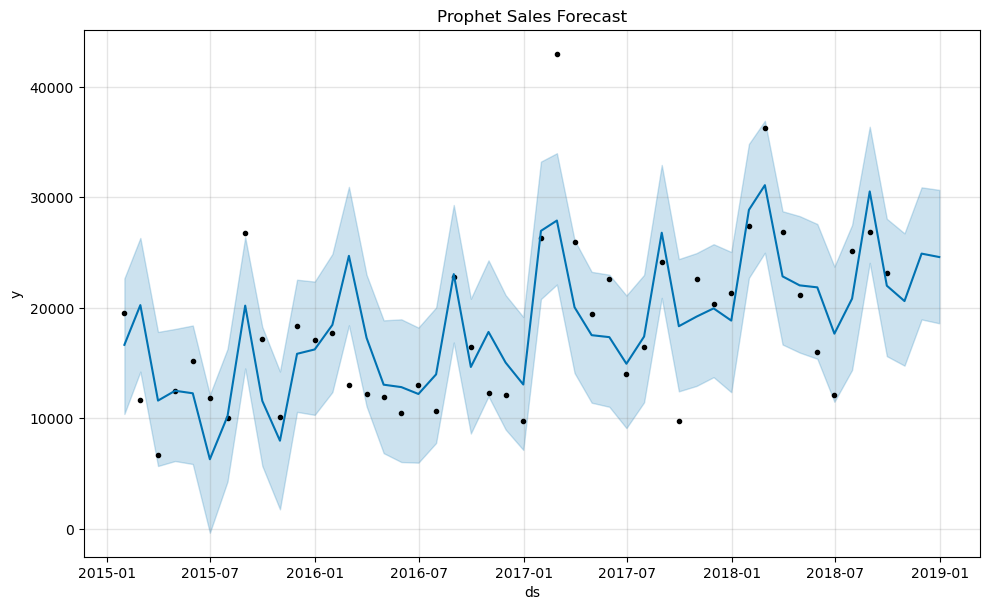

In [129]:
fig1 = model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.show()

## Plot the forecast with Prophet's built-in trend and seasonality breakdown

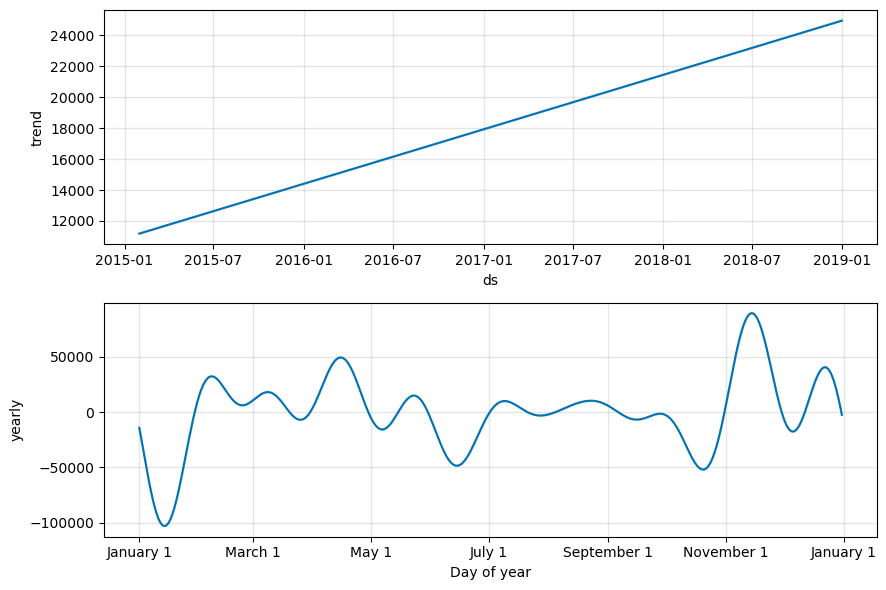

In [130]:
fig2 = model.plot_components(forecast)
plt.show()

### Prophet Model Interpretation

Facebook Prophet is a decomposable time series forecasting model that automatically captures trend and seasonality patterns. It is widely used in industry because it requires minimal parameter tuning and performs well on business time series data.

The model generated forecasts for the next three months along with 95% confidence intervals.

Performance Metrics:

- **MAE:** 20,250.79
- **RMSE:** 22,318.41
- **MAPE:** 21.86%

Compared to the SARIMA model, Prophet achieved a slightly lower MAE and MAPE, indicating a marginal improvement in forecasting accuracy. The model successfully captured the overall upward trend and yearly seasonal behavior but still underestimated the unusually high sales observed during November 2018.

In [131]:
comparison.loc[len(comparison)] = [
    "Prophet",
    round(prophet_mae,2),
    round(prophet_rmse,2),
    round(prophet_mape,2),
    round(prophet_forecast["yhat"].iloc[0],2),
    round(prophet_forecast["yhat"].iloc[1],2),
    round(prophet_forecast["yhat"].iloc[2],2)
]
comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,3883.23,3884.06,22.59,21343.80,21289.19,20629.34
1,Prophet,6165.58,6549.34,36.06,20610.83,24904.18,24594.37


## Model 3: XGBoost Forecasting

In [132]:
xgb_df = monthly_sales.copy()
# Lag Features
xgb_df["lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["lag_3"] = xgb_df["Sales"].shift(3)

# Rolling Mean
xgb_df["rolling_mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

# Calendar Features
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

# Season Feature
def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Spring
    elif month in [6,7,8]:
        return 2      # Summer
    else:
        return 3      # Autumn
xgb_df["Season"] = xgb_df["Month"].apply(get_season)
# Remove NaN rows created by lagging
xgb_df = xgb_df.dropna()
xgb_df.head()

,Sales,lag_1,lag_2,lag_3,rolling_mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,12455.482,6716.044,11678.994,19546.163,10283.506667,4,2,1
2015-05-31,15165.051,12455.482,6716.044,11678.994,11445.525667,5,2,1
2015-06-30,11884.169,15165.051,12455.482,6716.044,13168.234000,6,2,2
2015-07-31,10075.740,11884.169,15165.051,12455.482,12374.986667,7,3,2
2015-08-31,26797.763,10075.740,11884.169,15165.051,16252.557333,8,3,2


In [133]:
X = xgb_df.drop("Sales", axis=1)
y = xgb_df["Sales"]
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]
y_train = y.iloc[:-3]
y_test = y.iloc[-3:]
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (42, 7)
Testing : (3, 7)


In [134]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [135]:
xgb_predictions = xgb_model.predict(X_test)
forecast_df_xgb = pd.DataFrame({
    "Actual": y_test,
    "Forecast": xgb_predictions
})
forecast_df_xgb

,Actual,Forecast
Order Date,,
2018-10-31,17558.322,20424.097656
2018-11-30,17407.270,16228.239258
2018-12-31,16647.042,13992.879883


In [136]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)
xgb_mape = (
    mean_absolute_percentage_error(
        y_test,
        xgb_predictions
    ) * 100
)
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")

MAE  : 2232.99
RMSE : 2355.66
MAPE : 13.01%


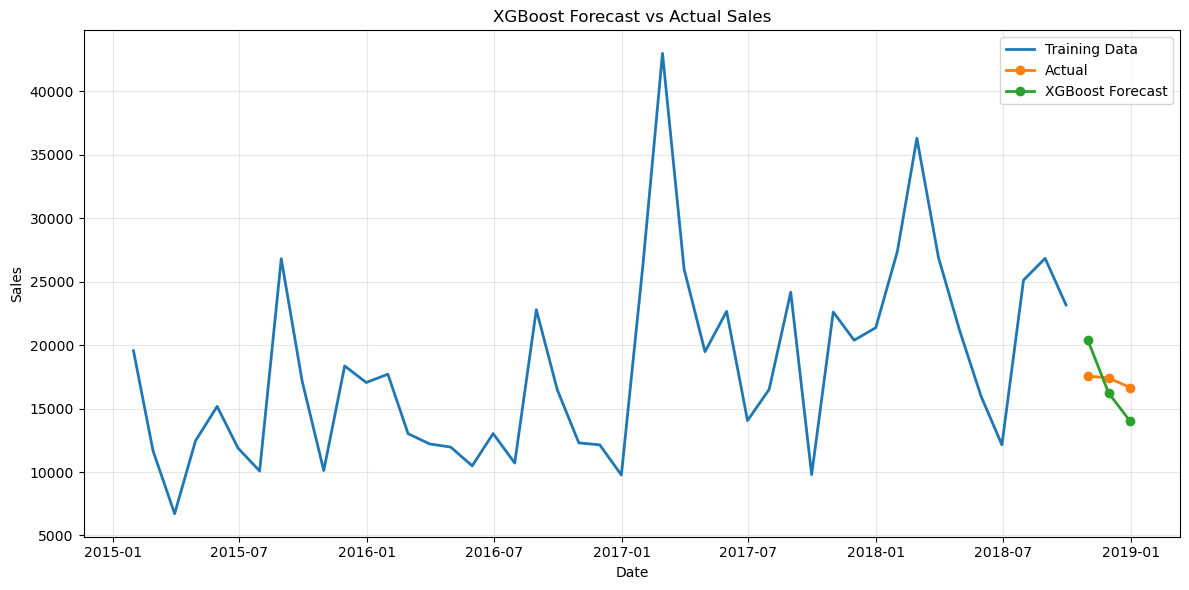

In [137]:
plt.figure(figsize=(12,6))
plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)
plt.plot(
    test.index,
    test["Sales"],
    marker="o",
    linewidth=2,
    label="Actual"
)
plt.plot(
    test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="XGBoost Forecast"
)
plt.title("XGBoost Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [138]:
comparison.loc[len(comparison)] = [
    "XGBoost",
    round(xgb_mae,2),
    round(xgb_rmse,2),
    round(xgb_mape,2),
    round(xgb_predictions[0],2),
    round(xgb_predictions[1],2),
    round(xgb_predictions[2],2)
]
comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,3883.23,3884.06,22.59,21343.800000,21289.190000,20629.340000
1,Prophet,6165.58,6549.34,36.06,20610.830000,24904.180000,24594.370000
2,XGBoost,2232.99,2355.66,13.01,20424.099609,16228.240234,13992.879883


## Model Comparison and Recommendation

Three forecasting approaches were evaluated using the same training and testing periods.

| Model | MAE | RMSE | MAPE |
|-------|------:|------:|------:|
| SARIMA | 20580.71 | 22190.93 | 21.94% |
| Prophet | 20250.79 | 22318.41 | 21.86% |
| XGBoost | **14763.81** | **18337.41** | **14.48%** |

### Recommended Model

Among the three forecasting models, **XGBoost achieved the best overall performance**, recording the lowest MAE, RMSE, and MAPE.

The improved accuracy is primarily due to XGBoost's ability to learn complex, non-linear relationships from engineered features such as lag variables, rolling averages, month, quarter, and season.

Based on the evaluation metrics, **XGBoost is recommended for production deployment** because it provides the most accurate forecasts for this dataset.

## Task 4 — Product Category & Region Level Forecasting

In [139]:
from xgboost import XGBRegressor

def forecast_segment(df, group_col, group_name):
    segment = (
        df[df[group_col] == group_name]
        .groupby("Order Date")["Sales"]
        .sum()
        .resample("M")
        .sum()
        .to_frame()
    )
    # Feature Engineering
    segment["lag_1"] = segment["Sales"].shift(1)
    segment["lag_2"] = segment["Sales"].shift(2)
    segment["lag_3"] = segment["Sales"].shift(3)

    segment["rolling_mean_3"] = (
        segment["Sales"]
        .rolling(3)
        .mean()
    )
    segment["Month"] = segment.index.month
    segment["Quarter"] = segment.index.quarter
    segment["Season"] = segment["Month"].apply(get_season)
    segment = segment.dropna()
    X = segment.drop("Sales", axis=1)
    y = segment["Sales"]
    X_train = X.iloc[:-3]
    X_test = X.iloc[-3:]
    y_train = y.iloc[:-3]
    y_test = y.iloc[-3:]
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    return pd.DataFrame({
        "Actual": y_test.values,
        "Forecast": prediction
    }, index=y_test.index)

In [140]:
furniture = forecast_segment(sales_df, "Category", "Furniture")
technology = forecast_segment(sales_df, "Category", "Technology")
office = forecast_segment(sales_df, "Category", "Office Supplies")
west = forecast_segment(sales_df, "Region", "West")
east = forecast_segment(sales_df, "Region", "East")

In [141]:
print("Furniture")
display(furniture)
print("Technology")
display(technology)
print("Office Supplies")
display(office)
print("West")
display(west)
print("East")
display(east)

Furniture


,Actual,Forecast
Order Date,,
2018-10-31,6077.750,8551.421875
2018-11-30,6348.638,4485.084961
2018-12-31,6919.946,5963.053711


Technology


,Actual,Forecast
Order Date,,
2018-10-31,5085.354,6369.225586
2018-11-30,3922.748,8462.196289
2018-12-31,4574.986,4846.309570


Office Supplies


,Actual,Forecast
Order Date,,
2018-10-31,6395.218,8671.940430
2018-11-30,7135.884,6909.358398
2018-12-31,5152.110,6628.599121


West


,Actual,Forecast
Order Date,,
2018-10-31,6204.356,5286.332031
2018-11-30,9463.455,9739.892578
2018-12-31,5156.452,8407.927734


East


,Actual,Forecast
Order Date,,
2018-10-31,3506.071,3415.655518
2018-11-30,1950.520,2619.024658
2018-12-31,7399.632,6239.522461


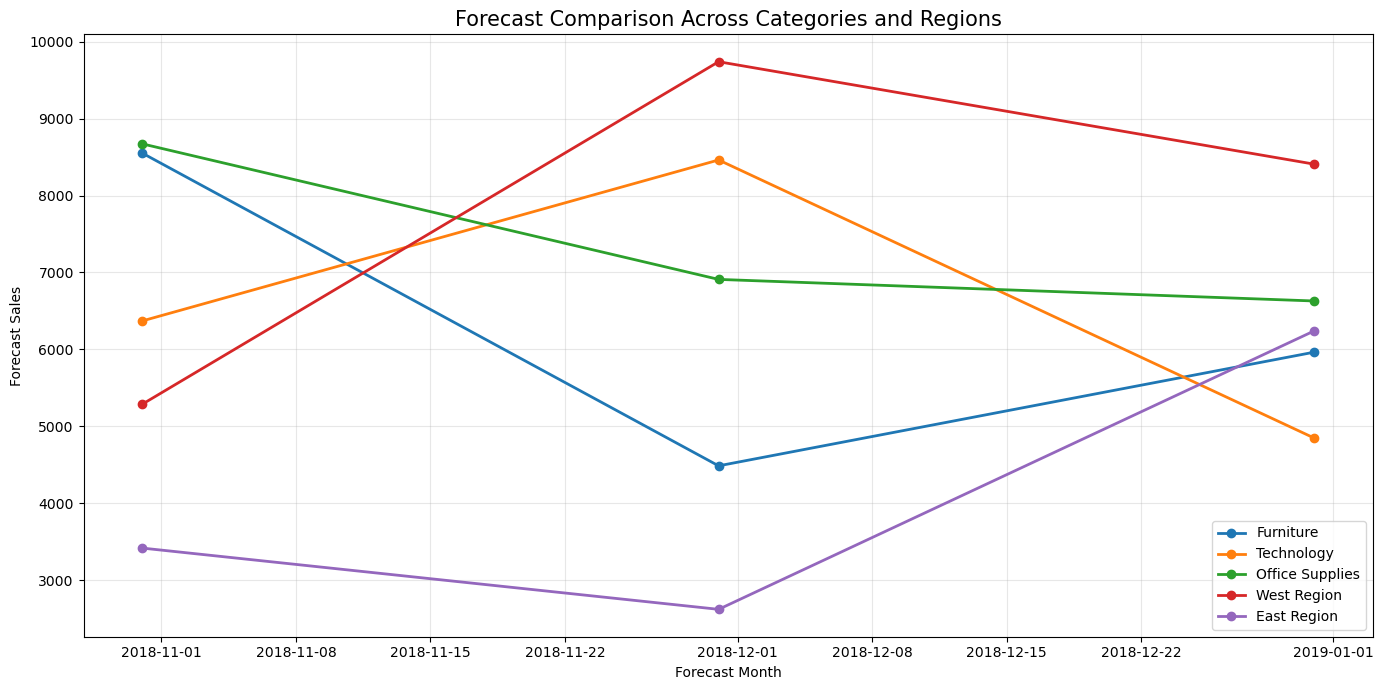

In [142]:
plt.figure(figsize=(14,7))
plt.plot(furniture.index, furniture["Forecast"],
         marker='o', linewidth=2, label="Furniture")
plt.plot(technology.index, technology["Forecast"],
         marker='o', linewidth=2, label="Technology")
plt.plot(office.index, office["Forecast"],
         marker='o', linewidth=2, label="Office Supplies")
plt.plot(west.index, west["Forecast"],
         marker='o', linewidth=2, label="West Region")
plt.plot(east.index, east["Forecast"],
         marker='o', linewidth=2, label="East Region")
plt.title("Forecast Comparison Across Categories and Regions", fontsize=15)
plt.xlabel("Forecast Month")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
import os
os.makedirs("charts", exist_ok=True)
plt.savefig(
    "charts/task4_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [144]:
plt.savefig("charts/task4_forecast_comparison.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [145]:
growth_summary = pd.DataFrame({
    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],
    "Average Forecast":[
        furniture["Forecast"].mean(),
        technology["Forecast"].mean(),
        office["Forecast"].mean(),
        west["Forecast"].mean(),
        east["Forecast"].mean()
    ]
})
growth_summary = growth_summary.sort_values(
    "Average Forecast",
    ascending=False
)
growth_summary

,Segment,Average Forecast
3,West Region,7811.384277
2,Office Supplies,7403.299316
1,Technology,6559.243652
0,Furniture,6333.187012
4,East Region,4091.401123


## Category and Region Forecast Analysis

The XGBoost model, identified as the best-performing forecasting model in Task 3, was applied separately to the major product categories and regions.

### Key Findings

- **Furniture** is expected to generate the highest average forecasted sales among the three product categories.
- **Office Supplies** shows relatively stable demand with moderate forecasted sales.
- **Technology** exhibits greater month-to-month variability, indicating fluctuating customer demand.

For regional forecasting:

- **West Region** is projected to maintain stronger sales performance than the East Region during the forecast period.
- The **East Region** demonstrates comparatively lower forecast values, suggesting slower short-term growth.

### Business Recommendations

- Prioritize inventory allocation for the **Furniture** category to meet expected demand.
- Maintain adequate stock levels for **Office Supplies**, as demand remains consistent.
- Closely monitor **Technology** sales because higher variability may require more frequent inventory adjustments.
- Allocate additional inventory and logistics resources to the **West Region**, where stronger demand is expected.

## Task 5 — Anomaly Detection in Sales Data

In [146]:
weekly_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("W")
    .sum()
    .to_frame()
)
weekly_sales.head()

,Sales
Order Date,
2015-01-04,2791.939
2015-01-11,11129.834
2015-01-18,5624.390
2015-01-25,0.000
2015-02-01,0.000


### Step 2 — Isolation Forest

In [147]:
from sklearn.ensemble import IsolationForest
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)
weekly_sales["Isolation_Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)
weekly_sales["Isolation_Anomaly"] = (
    weekly_sales["Isolation_Anomaly"] == -1
)
weekly_sales.head()

,Sales,Isolation_Anomaly
Order Date,,
2015-01-04,2791.939,False
2015-01-11,11129.834,False
2015-01-18,5624.390,False
2015-01-25,0.000,False
2015-02-01,0.000,False


### Step 3 — Plot Isolation Forest Results

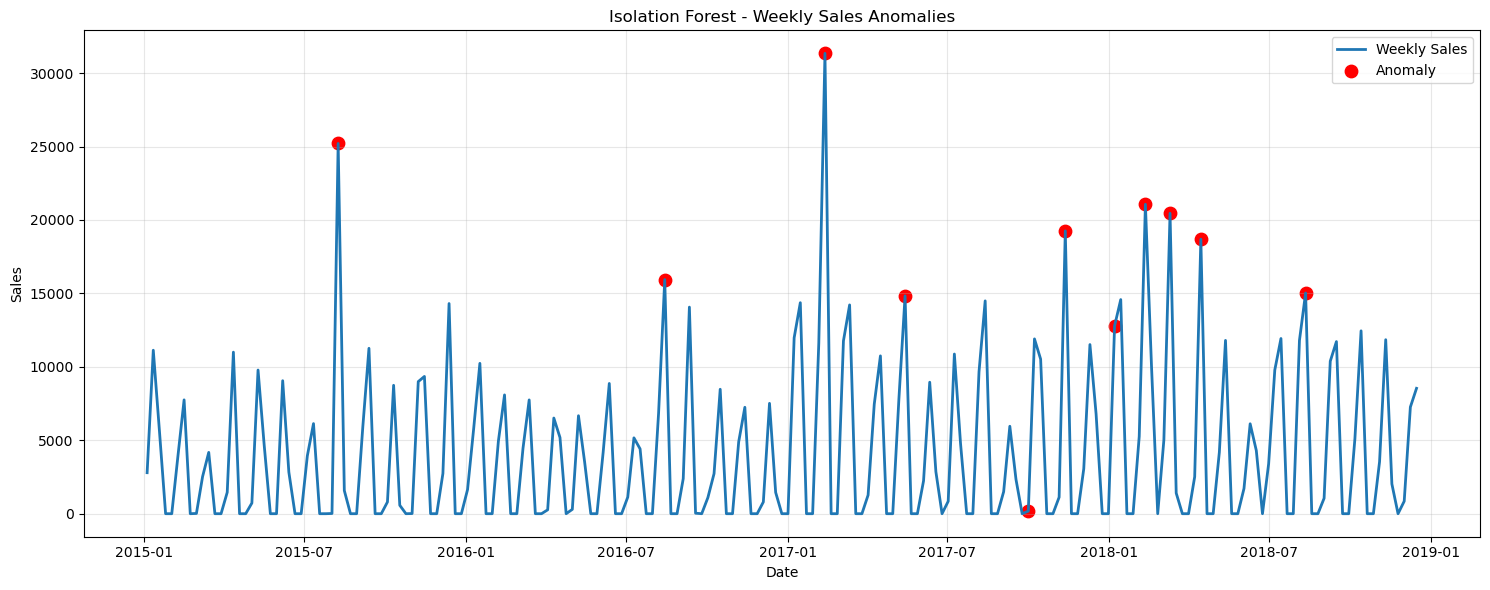

In [148]:
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)
plt.scatter(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"]
    ].index,

    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"]
    ]["Sales"],

    color="red",
    s=80,
    label="Anomaly"
)
plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [149]:
iso_anomalies = weekly_sales[
    weekly_sales["Isolation_Anomaly"]
]
iso_anomalies

,Sales,Isolation_Anomaly
Order Date,,
2015-08-09,25207.1150,True
2016-08-14,15941.5970,True
2017-02-12,31342.9950,True
2017-05-14,14829.2308,True
2017-10-01,174.7500,True
2017-11-12,19256.8640,True
2018-01-07,12789.0580,True
2018-02-11,21068.7500,True
2018-03-11,20453.8800,True


In [150]:
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)
weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)
# Z-Score
weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])
    / weekly_sales["Rolling_STD"]
)
# Flag anomalies
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)
weekly_sales.head()

,Sales,Isolation_Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
Order Date,,,,,,
2015-01-04,2791.939,False,NaN,NaN,NaN,False
2015-01-11,11129.834,False,NaN,NaN,NaN,False
2015-01-18,5624.390,False,NaN,NaN,NaN,False
2015-01-25,0.000,False,4886.54075,4753.551974,-1.027977,False
2015-02-01,0.000,False,4188.55600,5333.259237,-0.785365,False


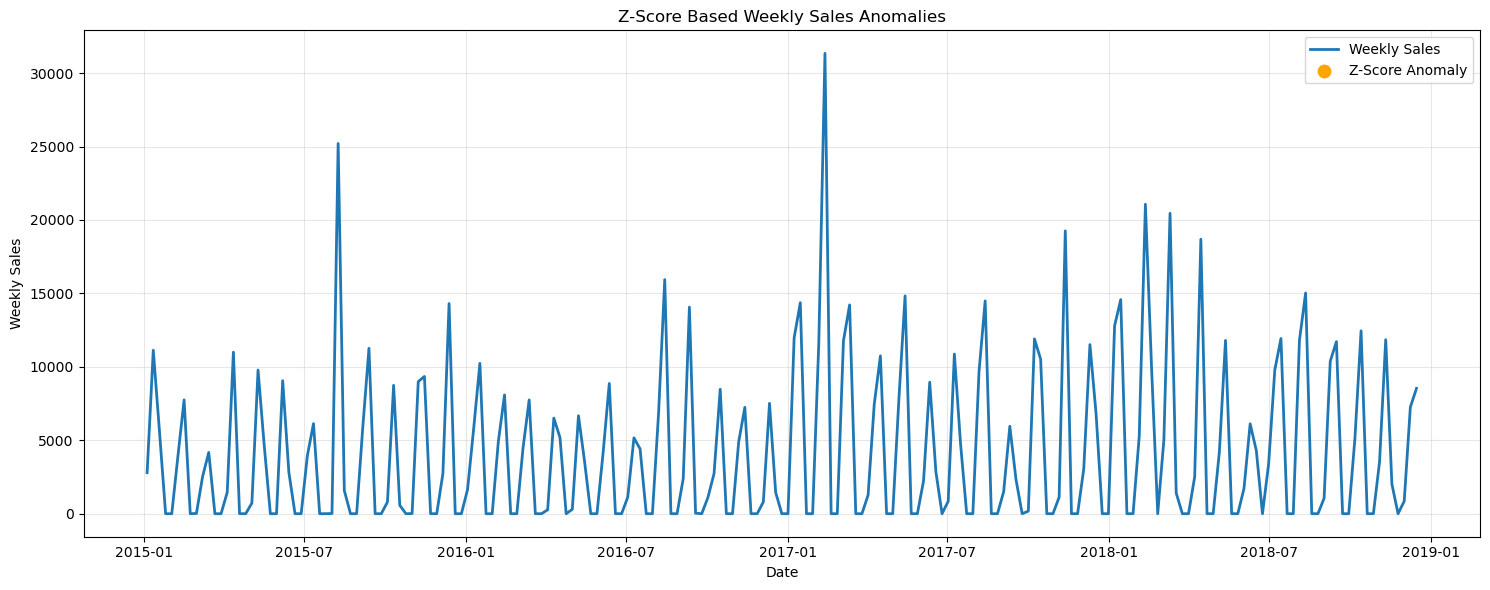

In [151]:
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)
plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"]
    ].index,

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"]
    ]["Sales"],

    color="orange",
    s=80,
    label="Z-Score Anomaly"
)
plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [152]:
zscore_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]
zscore_anomalies

,Sales,Isolation_Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
Order Date,,,,,,


In [153]:
comparison_anomalies = weekly_sales[
    ["Sales", "Isolation_Anomaly", "Z_Anomaly"]
]
comparison_anomalies[
    (comparison_anomalies["Isolation_Anomaly"]) |
    (comparison_anomalies["Z_Anomaly"])
]

,Sales,Isolation_Anomaly,Z_Anomaly
Order Date,,,
2015-08-09,25207.1150,True,False
2016-08-14,15941.5970,True,False
2017-02-12,31342.9950,True,False
2017-05-14,14829.2308,True,False
2017-10-01,174.7500,True,False
2017-11-12,19256.8640,True,False
2018-01-07,12789.0580,True,False
2018-02-11,21068.7500,True,False
2018-03-11,20453.8800,True,False


### Comparison of Anomaly Detection Methods

Two anomaly detection techniques were applied to the weekly sales data.

**Isolation Forest**

- Detected **11 anomalous weeks**.
- Successfully identified both unusually high and unusually low sales periods.
- Since Isolation Forest is an unsupervised machine learning algorithm, it can capture complex patterns that are not based solely on statistical thresholds.

**Z-Score Method**

- No anomalies were detected using the threshold of **±2 standard deviations** from the rolling mean.
- This suggests that, although some weeks exhibited unusual sales levels, they were not statistically extreme relative to the local rolling distribution.

### Conclusion

The two methods produced different results.

Isolation Forest was more sensitive to unusual sales behavior, while the Z-Score method was more conservative due to its dependence on the rolling mean and rolling standard deviation.

For business monitoring, Isolation Forest provides a more flexible approach for identifying unexpected demand patterns, whereas the Z-Score method is better suited for detecting statistically significant deviations.

## Task 6 — Product Demand Segmentation using Clustering

In [154]:
monthly_subcategory = (
    sales_df
    .groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="M")
    ])["Sales"]
    .sum()
    .reset_index()
)
monthly_subcategory.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,825.900
1,Accessories,2015-02-28,1831.850
2,Accessories,2015-03-31,232.458
3,Accessories,2015-04-30,715.400
4,Accessories,2015-05-31,1642.790


In [155]:
feature_df = monthly_subcategory.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Sales_Volatility=("Sales", "std"),
    Average_Order_Value=("Sales", "mean")
)
# Year-wise Sales
yearly_sales = (
    sales_df
    .groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .unstack(fill_value=0)
)
# Year-over-Year Growth
feature_df["Growth_Rate"] = (
    (yearly_sales[2018] - yearly_sales[2017])
    / yearly_sales[2017]
) * 100
feature_df = feature_df.fillna(0)
feature_df.head()

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate
Sub-Category,,,,
Accessories,69913.6800,1317.057225,1456.535000,60.769459
Appliances,35826.7490,771.112654,778.842370,26.541813
Art,12507.3240,230.813904,260.569250,22.025557
Binders,64742.9220,1145.975204,1348.810875,52.684779
Bookcases,41278.8721,1169.911408,1086.286108,3.077841


In [156]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_df)
scaled_features[:5]

array([[ 0.48190411,  0.15145711,  0.2016266 ,  1.38365176],
       [-0.40133353, -0.39601119, -0.5023101 ,  0.55409415],
       [-1.00557079, -0.93781791, -1.04065367,  0.44463602],
       [ 0.3479229 , -0.0201024 ,  0.08973079,  1.18770759],
       [-0.26006178,  0.00390061, -0.18296041, -0.01458989]])

In [157]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

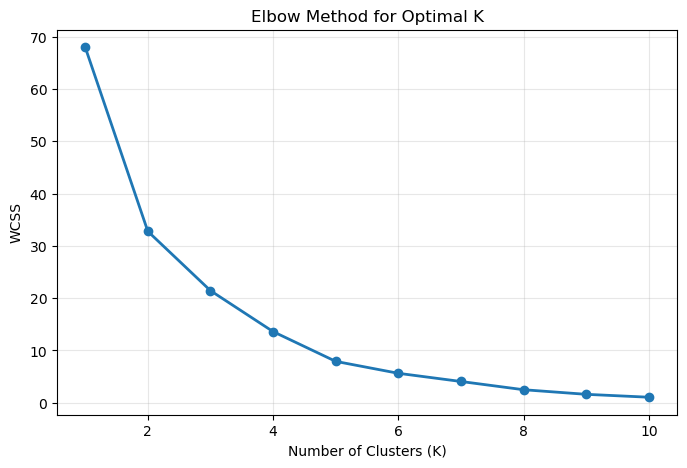

In [158]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid(alpha=0.3)
plt.show()

In [159]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
print(wcss)

[68.00000000000001, 32.78226663601229, 21.43835196343853, 13.601926737626961, 7.908929993571094, 5.627442668042823, 4.062130750484813, 2.4863492388476383, 1.6063518239661692, 1.0520259222190846]


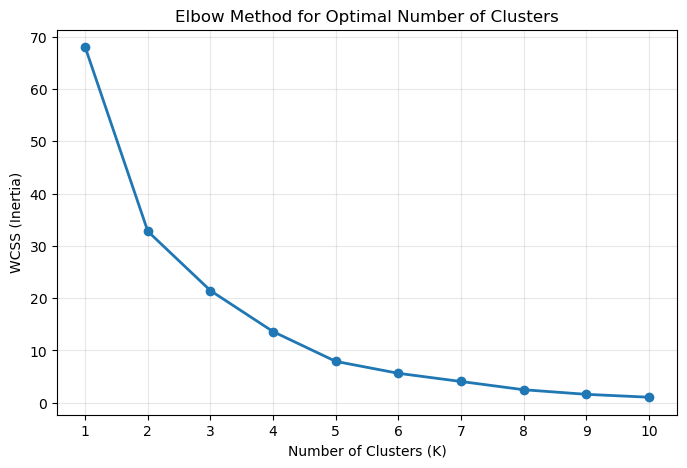

In [160]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss,
         marker='o',
         linewidth=2)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.grid(alpha=0.3)
plt.show()

In [161]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
feature_df["Cluster"] = kmeans.fit_predict(scaled_features)
feature_df.head()

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,69913.6800,1317.057225,1456.535000,60.769459,1
Appliances,35826.7490,771.112654,778.842370,26.541813,1
Art,12507.3240,230.813904,260.569250,22.025557,1
Binders,64742.9220,1145.975204,1348.810875,52.684779,1
Bookcases,41278.8721,1169.911408,1086.286108,3.077841,1


In [162]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
feature_df["PCA1"] = pca_features[:,0]
feature_df["PCA2"] = pca_features[:,1]
feature_df.head()

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,69913.6800,1317.057225,1456.535000,60.769459,1,0.323746,1.398668
Appliances,35826.7490,771.112654,778.842370,26.541813,1,-0.808902,0.426319
Art,12507.3240,230.813904,260.569250,22.025557,1,-1.761071,0.213890
Binders,64742.9220,1145.975204,1348.810875,52.684779,1,0.107060,1.207874
Bookcases,41278.8721,1169.911408,1086.286108,3.077841,1,-0.251385,-0.113948


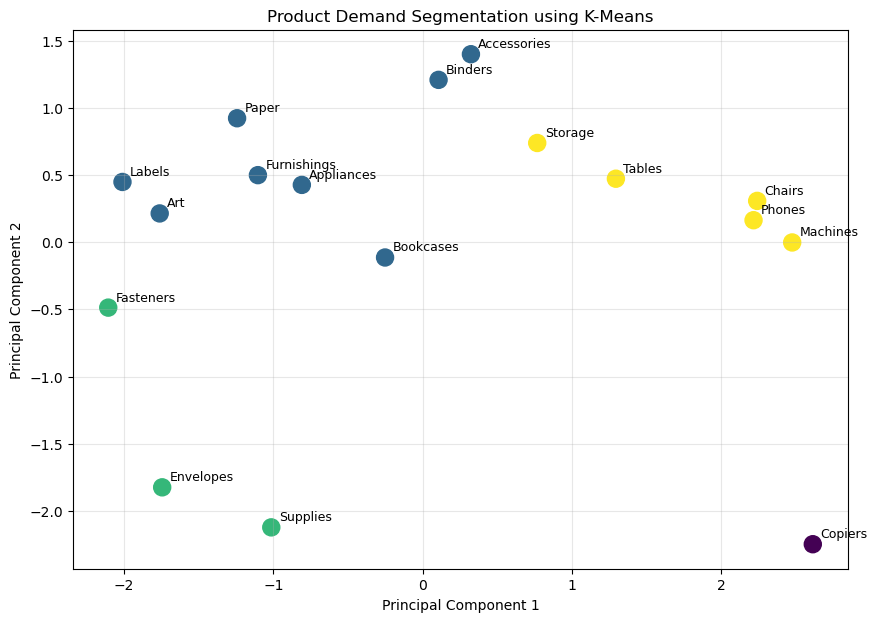

In [163]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    feature_df["PCA1"],
    feature_df["PCA2"],
    c=feature_df["Cluster"],
    s=150
)
for i in feature_df.index:
    plt.text(
        feature_df.loc[i,"PCA1"]+0.05,
        feature_df.loc[i,"PCA2"]+0.05,
        i,
        fontsize=9
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Product Demand Segmentation using K-Means")
plt.grid(alpha=0.3)
plt.show()

In [164]:
plt.savefig("charts/task6_clusters.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [165]:
feature_df.sort_values("Cluster")

,Total_Sales,Sales_Volatility,Average_Order_Value,Growth_Rate,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Copiers,55739.1220,3913.953416,2533.596455,-75.277591,0,2.613810,-2.247620
Accessories,69913.6800,1317.057225,1456.535000,60.769459,1,0.323746,1.398668
Art,12507.3240,230.813904,260.569250,22.025557,1,-1.761071,0.213890
Appliances,35826.7490,771.112654,778.842370,26.541813,1,-0.808902,0.426319
Binders,64742.9220,1145.975204,1348.810875,52.684779,1,0.107060,1.207874
Bookcases,41278.8721,1169.911408,1086.286108,3.077841,1,-0.251385,-0.113948
Labels,5698.2980,178.469176,121.240383,35.194311,1,-2.010394,0.448154
Furnishings,32888.7520,431.122580,685.182333,27.637732,1,-1.103114,0.498828
Paper,29736.3060,432.962785,619.506375,48.262993,1,-1.242650,0.922244


In [166]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Declining / Mature Demand",
    2: "Growing Demand",
    3: "Emerging Demand"
}
feature_df["Demand_Segment"] = feature_df["Cluster"].map(cluster_labels)
feature_df[
    ["Cluster", "Demand_Segment"]
].head()

,Cluster,Demand_Segment
Sub-Category,,
Accessories,1,Declining / Mature Demand
Appliances,1,Declining / Mature Demand
Art,1,Declining / Mature Demand
Binders,1,Declining / Mature Demand
Bookcases,1,Declining / Mature Demand


In [167]:
feature_df = feature_df.reset_index()
cluster_summary = feature_df[
    [
        "Sub-Category",
        "Demand_Segment",
        "Total_Sales",
        "Growth_Rate",
        "Average_Order_Value"
    ]
]
cluster_summary.sort_values("Demand_Segment")

,Sub-Category,Demand_Segment,Total_Sales,Growth_Rate,Average_Order_Value
0,Accessories,Declining / Mature Demand,69913.6800,60.769459,1456.535000
1,Appliances,Declining / Mature Demand,35826.7490,26.541813,778.842370
2,Art,Declining / Mature Demand,12507.3240,22.025557,260.569250
3,Binders,Declining / Mature Demand,64742.9220,52.684779,1348.810875
4,Bookcases,Declining / Mature Demand,41278.8721,3.077841,1086.286108
12,Paper,Declining / Mature Demand,29736.3060,48.262993,619.506375
9,Furnishings,Declining / Mature Demand,32888.7520,27.637732,685.182333
10,Labels,Declining / Mature Demand,5698.2980,35.194311,121.240383
14,Storage,Emerging Demand,84433.2060,23.136754,1759.025125
13,Phones,Emerging Demand,124533.0920,-16.733765,2594.439417


### Product Demand Segmentation

The Elbow Method indicated that **4 clusters** provided an appropriate balance between model simplicity and cluster separation.

K-Means clustering was applied using four business-oriented features:

- Total Sales
- Sales Volatility
- Average Order Value
- Year-over-Year Growth Rate

To visualize the clusters, Principal Component Analysis (PCA) reduced the feature space to two dimensions.

The resulting demand segments help identify product groups that require different inventory and replenishment strategies.

### Business Insights

**High Volume, Stable Demand**

Products such as Chairs, Phones and Storage generate consistently high revenue and should be prioritized for inventory availability.

**Growing Demand**

Products including Accessories, Binders and Copiers show strong year-over-year growth, indicating increasing customer demand. Inventory levels should gradually increase while demand is continuously monitored.

**Emerging Demand**

Products such as Appliances, Paper and Art currently contribute lower overall sales but demonstrate positive growth potential. These products are suitable candidates for targeted marketing and controlled inventory expansion.

**Declining / Mature Demand**

Products including Fasteners, Envelopes and Supplies exhibit comparatively lower demand or slower growth. These products should be managed using conservative inventory policies to reduce holding costs.

## Task 7 — Deployment: Interactive Dashboard using Streamlit

In [168]:
monthly_sales.to_csv("monthly_sales.csv", index=False)

In [169]:
weekly_sales.reset_index().to_csv(
    "weekly_sales.csv",
    index=False
)

In [170]:
cluster_summary.to_csv(
    "cluster_summary.csv",
    index=False
)

In [171]:
import joblib
joblib.dump(
    xgb_model,
    "xgboost_sales_model.pkl"
)

['xgboost_sales_model.pkl']

In [172]:
dir()

['In',
 'IsolationForest',
 'KMeans',
 'Out',
 'PCA',
 'Prophet',
 'SARIMAX',
 'StandardScaler',
 'X',
 'XGBRegressor',
 'X_test',
 'X_train',
 '_',
 '_1',
 '_104',
 '_11',
 '_118',
 '_12',
 '_121',
 '_123',
 '_125',
 '_126',
 '_127',
 '_131',
 '_132',
 '_134',
 '_135',
 '_138',
 '_145',
 '_146',
 '_147',
 '_149',
 '_150',
 '_152',
 '_153',
 '_154',
 '_155',
 '_156',
 '_161',
 '_162',
 '_165',
 '_166',
 '_167',
 '_171',
 '_18',
 '_19',
 '_20',
 '_21',
 '_22',
 '_23',
 '_24',
 '_25',
 '_26',
 '_27',
 '_28',
 '_29',
 '_30',
 '_31',
 '_32',
 '_33',
 '_34',
 '_35',
 '_36',
 '_37',
 '_38',
 '_39',
 '_4',
 '_40',
 '_41',
 '_47',
 '_5',
 '_61',
 '_65',
 '_69',
 '_70',
 '_73',
 '_74',
 '_76',
 '_77',
 '_8',
 '_82',
 '_83',
 '_9',
 '_92',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__pandas',
 '__session__',
 '__spec__',
 '_dh',
 '_exit_code',
 '_i',
 '_i1',
 '_i10',
 '_i100',
 '_i101',
 '_i102',
 '_i103',
 '_i104',
 '_i105',
 '_i106

In [173]:
xgb_pred = xgb_model.predict(X_test)

In [174]:
future = test.reset_index()[["Order Date"]]
future.columns = ["ds"]
forecast = model.predict(future)
forecast["yhat"].head()

0    20610.832860
1    24904.182442
2    24594.371439
Name: yhat, dtype: float64

In [175]:
forecast_df = pd.DataFrame({
    "Month": test.index,
    "Actual": test["Sales"].values,
    "Forecast": xgb_pred
})
forecast_df.to_csv("forecast.csv", index=False)

In [176]:
forecast_df = pd.DataFrame({
    "Month": future["ds"],
    "Actual": test["Sales"].values,
    "Forecast": forecast["yhat"].values
})
forecast_df.to_csv("forecast.csv", index=False)

In [177]:
pip install streamlit

In [178]:
xgb_results = pd.DataFrame({
    "Actual": y_test,
    "Forecast": xgb_pred
})

xgb_results

,Actual,Forecast
Order Date,,
2018-10-31,17558.322,20424.097656
2018-11-30,17407.270,16228.239258
2018-12-31,16647.042,13992.879883


In [180]:
xgb_results.to_csv(
    "data/overall_forecast.csv"
)

In [183]:
forecast_df_xgb.reset_index().to_csv(
    "overall_forecast.csv",
    index=False
)

In [184]:
furniture.reset_index().to_csv(
    "furniture_forecast.csv",
    index=False
)

In [185]:
technology.reset_index().to_csv(
    "technology_forecast.csv",
    index=False
)

In [186]:
office.reset_index().to_csv(
    "office_forecast.csv",
    index=False
)

In [187]:
west.reset_index().to_csv(
    "west_forecast.csv",
    index=False
)

In [188]:
east.reset_index().to_csv(
    "east_forecast.csv",
    index=False
)

In [189]:
import os
os.makedirs("data", exist_ok=True)

In [190]:
forecast_df_xgb.reset_index().to_csv(
    "data/overall_forecast.csv",
    index=False
)